In [19]:
import os

# Change cwd to the notebook's directory for VS Code 
try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("Could not find notebook path. Running from:", os.getcwd())

Could not find notebook path. Running from: /Users/irene.bonafonte/Documents/PhD/Projects/2025Feb_Dextraminer/DextraDemixer/experiments/Ioanna_data


In [20]:
import sys 

sys.path.append("../../")

import numpyro as npy
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir
import itertools as itr
import seaborn as sns
import resource

from matplotlib import pyplot as plt, cm as mpl_cm
import matplotlib as mpl
from cycler import cycler
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import classification_report, average_precision_score, precision_score, recall_score, accuracy_score, confusion_matrix, f1_score, roc_auc_score, matthews_corrcoef

import mudata as md
from mudata import MuData, AnnData
import muon as mu
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mudata")

from IPython.display import Markdown

from dextrademixer.model import DextraDemixer, BEAMT, ITRAP,  ICON
from dextrademixer.utils import calculate_metrics

pd.set_option('display.max_columns', 200)
# mu.set_options(pull_on_update=True) 

/Users/irene.bonafonte/miniforge3/envs/dextrademixer26/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/irene.bonafonte/miniforge3/envs/dextrademixer26/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/Users/irene.bonafonte/miniforge3/envs/dextrademixer26/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plot settings

In [4]:
sns.reset_defaults()

global_settings = {
'font.size': 12, 'axes.titlesize': 'large', 'axes.labelsize': 'medium', 'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium', 'legend.fontsize': 'medium', 'figure.titlesize': 'large',
    'figure.figsize': (3, 2.5), 'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.transparent': True,
}
plt.rcParams.update(global_settings)
os.makedirs('figures', exist_ok=True)

hue_order = ['itrap', 'iconFaith', 'icon', 'beamt', 'dextrademixer']
method_palette = {'iconFaith':'#fdb863', 'icon':'#e08214', 'itrap':'#c51b7d', 'beamt': "#2b8cbe", "dextrademixer":  "#8073ac"}
plt.rcParams.update({ 'axes.spines.top': False, 'axes.spines.right': False, })

In [20]:
def plot_confusion_hist(x_umi, ground_truth, assignment, title='', ax=None):
    mask = ~np.isnan(ground_truth)
    confusion_df = pd.DataFrame({'x_umi': x_umi[mask], 'True': ground_truth[mask], 'Predicted': assignment[mask]})
    conditions = [ (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 0.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 0.0) ]
    choices = [ 'True Negative', 'True Positive', 'False Positive', 'False Negative' ]
    confusion_df['Outcome'] = np.select(conditions, choices, default='Unknown')

    custom_palette = { 'True Negative': '#8DB4E2', 'True Positive': '#1F4E79', 'False Positive': '#C00000', 'False Negative': '#FFC000'}
    ax = sns.histplot(
        data=confusion_df, x='x_umi', hue='Outcome', palette=custom_palette, hue_order=choices, bins=100, 
        multiple="stack", edgecolor="white", linewidth=0.5, ax=ax
    )
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(0.3, 1), frameon=False, ncols=1)
    ax.set_yscale('log')
    sns.despine()
    return ax

def print_evaluation(y_true, y_pred, adata=None, clone=None, adata_full=None, filter_bool=None):
    filter_bool = np.ones(y_true.shape).astype(bool) if filter_bool is None else filter_bool
    y_true, y_pred = y_true[filter_bool], y_pred[filter_bool]
    tn, fp, fn, tp = confusion_matrix(y_true[~np.isnan(y_true)], y_pred[~np.isnan(y_true)]).ravel().tolist()
    precision = tp / (tp+fp)
    recall = tp / (tp + fn)
    if precision + recall > 0:
        print(f'sensitivity: {recall}; specificity: {tn/(tn+fp)}; F1: {2*precision*recall / (precision+recall)}; accuracy: {(tp+tn)/(tp+tn+fp+fn)}; TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    else:
        print(f'sensitivity: {recall}; specificity: {tn/(tn+fp)}; F1: 0; accuracy: {(tp+tn)/(tp+tn+fp+fn)}; TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    if adata is not None and clone is not None:
        adata.obs[f'{clone}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])
        adata.obs.loc[filter_bool,f'{clone}_classification'] = np.where(y_true==1, np.where(y_pred==1, 'TP', 'FN'), np.where(y_pred==1, 'FP', 'TN'))
        ax = mu.pl.embedding(adata_full, basis='rna:wnn.umap', s=10, alpha=1, return_fig=True) if adata_full else None
        if adata_full:
            ax = ax.axes[0]
        mu.pl.embedding(
            adata, basis='rna:wnn.umap', color=[f'{clone}_classification'], palette = ['royalblue','lightsteelblue','brown','rosybrown','darkgrey'], 
            ncols=1, wspace=0.5, frameon=False, s=10, ax=ax
        )
        return adata
    return

# Helper functions

In [19]:
# Helper function:
dex_map ={"HLA-A*0201": "DexA", "HLA-C*0702":"DexC", "HLA-B*0801":"DexN", "HLA-B*0702":"DexB"}
dex_map_rev ={"DexA":"HLA-A*0201", "DexC":"HLA-C*0702", "DexN":"HLA-B*0801", "DexB":"HLA-B*0702"}

def run_BEAMT(
    mdat,
    pmhc_key="HLA-A*0201",
    gex_key="rio",
    ir_key="airr",
    neg_ctrl_key="HLA-B*0801",
    threshold=0.5,
    target_fdr=None
):
    mixer = BEAMT()
    mixer.preprocess_model_data(mdat, pmhc_key=pmhc_key, gex_key=gex_key, neg_ctrl_key=neg_ctrl_key, ir_key=ir_key)
    mixer.fit()
    p_pred, assignment = mixer.predict_posterior_class(target_fdr=target_fdr, threshold=threshold)
    mdat.obs[f'beamt_{dex_map[pmhc_key]}'] = assignment.__array__()
    mdat.obs[f'beamt_{dex_map[pmhc_key]}_p'] = p_pred.__array__()
    return mdat


def run_dextrademixer(
    mdat,
    pmhc_key="HLA-A*0201",
    gex_key="rio",
    ir_key="airr",
    neg_ctrl_key="HLA-B*0801",
    clone_id_key='clone_id',
    threshold=0.5,
    target_fdr=None
):
    # hyper parameters
    seed, alpha_offset, hyperprior, use_size_factor, outlier_threshold = 42, 5, 1.0, True, None
    opt_params = {"maxiter": 1000, "nof_inits": 10, "adam": {"init_value": 3e-1, "end_value": 3e-3, "decay_rate": 0.995, "transition_steps": 1}, }

    # set missing clones
    clone_id = mdat.obs[f'{ir_key}:{clone_id_key}'].astype(float).copy()
    max_id = clone_id.max()
    num_nans = clone_id.isna().sum()
    clone_id[clone_id.isna()] = np.arange(max_id, max_id+num_nans)

    # run model
    mixer = DextraDemixer(
        model_type='mixturemodelkmeans', mode='I', alpha_model='overdispersion',
        model_config={"overdispersion_scale_prior": hyperprior, "alpha_offset": alpha_offset}
    )
    mixer.preprocess_model_data(mdat, pmhc_key=pmhc_key, gex_key=gex_key, neg_ctrl_key=neg_ctrl_key, ir_key=ir_key)
    mixer.fit_svi(guide='normal', svi_config=opt_params, nof_inits=opt_params["nof_inits"], rng_key=42, y_true=None)
    samples = mixer.get_posterior_samples()
    p_pred, assignment = mixer.predict_posterior_class(threshold=0.5, clonotype_mean_p=True, clone_id=clone_id)
    mdat.obs[f'dextrademixer_{dex_map[pmhc_key]}'] = assignment.__array__()
    mdat.obs[f'dextrademixer_{dex_map[pmhc_key]}_p'] = p_pred.__array__()
    return mdat


def eval_results(y_true, y_pred, p_pred=False, adata=None, method=None):
    mask = ~np.isnan(y_true)
    tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask]).ravel()
    tpr = tp / (tp + fn)
    fdr = fp / (tp + fp)

    results = pd.Series()
    if np.any(p_pred):
        results['roc_auc'] = roc_auc_score(y_true[mask].astype(int), p_pred[mask])
        results['pr_auc'] = average_precision_score(y_true[mask].astype(int), p_pred[mask])
    else:
        results['roc_auc'], results['pr_auc'] = np.nan, np.nan
    results['f1'] = f1_score(y_true[mask].astype(int), y_pred[mask])
    results['precision'] = precision_score(y_true[mask].astype(int), y_pred[mask])
    results['recall'] = recall_score(y_true[mask].astype(int), y_pred[mask])
    results['accuracy'] = accuracy_score(y_true[mask].astype(int), y_pred[mask])
    results['mcc'] = matthews_corrcoef(y_true[mask].astype(int), y_pred[mask])
    results['fdr'] = fdr

    if adata:
        adata.obs[f'{method}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])
        adata.obs.loc[mask,f'{method}_classification'] = np.where(y_true[mask]==1, np.where(y_pred[mask]==1, 'TP', 'FN'), np.where(y_pred[mask]==1, 'FP', 'TN'))

    return results


# Prepare data

In [7]:
# needed to do
# with h5py.File("../../data/mudata_scanpy_new.h5mu", "r+") as f:
#    del f["mod/airr/uns/ir_dist_VDJDB_aa_identity/params/cutoff"]
#    del f["mod/airr/X"]
#    del f["mod/airr/uns/ir_dist_nt_identity/params/cutoff"]

# because this anndata version can't read elements with value ''null''
mdata = mu.read("../../data/mudata_scanpy_new.h5mu")
mdata.obs[['VDJ_1_umi_count','VJ_1_umi_count','VDJ_2_umi_count','VJ_2_umi_count']] = ir.get.airr(mdata, airr_variable=['umi_count'], chain=['VDJ_1', 'VJ_1', 'VDJ_2', 'VJ_2']).fillna(0)
mdata.pull_obs()

mdata

/Users/irene.bonafonte/miniforge3/envs/dextrademixer26/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/3664926641.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mdata.obs[['VDJ_1_umi_count','VJ_1_umi_count','VDJ_2_umi_count','VJ_2_umi_count']] = ir.get.airr(mdata, airr_variable=['umi_count'], chain=['VDJ_1', 'VJ_1', 'VDJ_2', 'VJ_2']).fillna(0)


MuData object with n_obs × n_vars = 9229 × 20154
  obs:	'VDJ_1_umi_count', 'VJ_1_umi_count', 'VDJ_2_umi_count', 'VJ_2_umi_count'
  uns:	'Cell_colors', 'Dex_colors', 'Sample_colors', 'cartridge_colors', 'cluster_colors', 'pca'
  obsm:	'AB', 'HTO', 'HTOflex', 'RNA', 'RiO', 'RiO_bg', 'X_pca', 'X_umap', 'X_wnn.umap', 'wnn.umap'
  varm:	'AB', 'HTO', 'HTOflex', 'PCs', 'RNA', 'RiO', 'RiO_bg'
  obsp:	'wknn', 'wsnn'
  7 modalities
    airr:	2835 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'cluster', 'Dex', 'clone_id', 'clone_id_size', 'antigen.species', 'antigen.gene'
      uns:	'chain_indices', 'clone_id', 'clonotype_network', 'ir_dist_VDJDB_aa_identity', 'ir_dist_nt_identity', 'ir_query_VDJDB_aa_identity', 'scirpy_version'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'
    rna:	9229 x 20107
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_HTOflex', 'nFeature_HTOflex', 'nReads_ALL', 'nReads_RNA', 'percent.mito', 'meanCount_RNA', 'meanCount_HTO', 'meanCount_HTOflex', 'HTOflex_maxID', 'HTOflex_secondID', 'HTOflex_margin', 'HTOflex_classification', 'HTOflex_classification.global', 'hash.ID', 'hash.ID.flex', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'tag.no', 'Sample', 'SpikeIn.pct', 'Background', 'Background.Donor', 'Background.pct', 'flex.tag.no', 'Cell', 'Type', 'Donor', 'Donor.long', 'Origin', 'Specificity', 'peptide.stim', 'CMV.peptide', 'Peptide.Seq', 'HLA.A.02.01', 'HLA.B.07.02', 'HLA.C.07.02', 'nCount_AB', 'nFeature_AB', 'nCount_RiO', 'nFeature_RiO', 'cartridge', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.5', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'AB.weight', 'wsnn_res.0.5', 'wsnn_res.0.5_anno', 'wsnn_res.0.5_old', 'wsnn_res.0.52', 'wsnn_res.0.52_anno', 'nCount_RiO_bg', 'nFeature_RiO_bg', 'cell_id', 'DexA', 'DexB', 'DexC', 'Dex', 'flex_tag_label', 'cluster', 'category'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable'
      uns:	'pca'
      obsm:	'X_pca', 'wnn.umap'
      varm:	'PCs'
      layers:	'counts', 'data'
    ab:	9229 x 31
      var:	'highly_variable'
      uns:	'apca'
      obsm:	'X_apca'
      varm:	'apca'
      layers:	'counts', 'data'
    rio:	9229 x 4
      layers:	'counts'
    rio_bg:	9229 x 3
      layers:	'counts', 'data'
    hto:	9229 x 4
      layers:	'counts'
    hto_flex:	9229 x 5
      layers:	'counts'

In [8]:
# These are the four samples: Donor 1 & 2, each with 5 or 50% theoretical spikein over all 3 clones (detected is less)
mdata.obs['rna:Sample'].value_counts(dropna=False)

rna:Sample
05-95-D2    2754
05-95-D1    2348
50-50-D1    2161
50-50-D2    1966
Name: count, dtype: int64

In [9]:
# Spike-in clones are True, HLA-mismatched BG are False (BG_D1 False for NLV, BG_D2 False for CRV)
# HLA-matched BG are nan because we don't know if there are some clonotypes that may bind
mdata.obs['NLV_true'] = np.where(mdata.obs["rna:flex_tag_label"] == 'NLV_Clone', 1, np.where(mdata.obs["rna:flex_tag_label"] =='BG_D1', np.nan, 0))
mdata.obs['CRV_true'] = np.where(mdata.obs["rna:flex_tag_label"] == 'CRV_Clone', 1, np.where(mdata.obs["rna:flex_tag_label"] == 'BG_D2', np.nan, 0))
mdata.obs['TPR_true'] = np.where((mdata.obs["rna:flex_tag_label"] == 'TPR_enriched') & (mdata.obs['rna:wsnn_res.0.5_anno'] == 'TPR_enriched_CD8_other'), 1, np.where(mdata.obs["rna:flex_tag_label"] == 'BG_D2', np.nan, 0))

In [10]:
mdata_wTCR = mdata[mdata['airr'].obs_names]

# Run methods

In [11]:
for dex_key in ['HLA-A*0201', 'HLA-C*0702', 'HLA-B*0702']:
    # BEAMT
    mdata = run_BEAMT(mdata, pmhc_key=dex_key)
    mdata_wTCR = run_BEAMT(mdata_wTCR, pmhc_key=dex_key)

    # Dextrademixer
    mdata = run_dextrademixer(mdata, pmhc_key=dex_key)
    mdata_wTCR = run_dextrademixer(mdata_wTCR, pmhc_key=dex_key)

/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/1231805166.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mdat.obs[f'beamt_{dex_map[pmhc_key]}'] = assignment.__array__()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 85.07it/s, avg. loss [991-1000]: 29537.8669]


In [12]:
icon_predictions = ICON.icon_assign_pmhc(
    mdata_wTCR, 
    ir_clone_key='airr:clone_id',
    neg_ctrl_key='HLA-B*0801',
    threshold=0,
    bg_noise=None,
    bg_noise_quantile=0.975,
    dex_key='rio',
)
icon_predictions = pd.DataFrame(icon_predictions, index=mdata_wTCR.obs_names, columns=['icon_DexA','icon_DexC','icon_DexB']).astype(int)
icon_predictions.head(3)

,icon_DexA,icon_DexC,icon_DexB
GAGGTGCTAAACTCATTGGATCTCTTA_1,0,0,1
ATTAAGTGCACTTCGAGCACGAACCAG_1,1,0,0
TGGCTCAGAACCAGGTGTTCCGTCTTA_1,0,0,1


In [13]:
icon_predictions_faithful = ICON.icon_assign_pmhc(
    mdata_wTCR, 
    ir_clone_key='airr:clone_id',
    neg_ctrl_key='HLA-B*0801',
    threshold=0,
    bg_noise=None,
    bg_noise_quantile=0.975,
    dex_key='rio',
    faithful=True
)
icon_predictions_faithful = pd.DataFrame(icon_predictions_faithful, index=mdata_wTCR.obs_names, columns=['iconFaith_DexA','iconFaith_DexC','iconFaith_DexB']).astype(int)
icon_predictions_faithful.head(3)

,iconFaith_DexA,iconFaith_DexC,iconFaith_DexB
GAGGTGCTAAACTCATTGGATCTCTTA_1,0,0,1
ATTAAGTGCACTTCGAGCACGAACCAG_1,0,0,0
TGGCTCAGAACCAGGTGTTCCGTCTTA_1,0,0,1


In [15]:
mixer = ITRAP.ITRAP(filters=['opt_thr']) #, 'specificity_multiplets']    )
mixer.preprocess_model_data(
    mdata_wTCR, neg_ctrl_key='HLA-B*0801', ir_key='airr', ir_clone_key='clone_id', dex_key='rio', 
    umi_cols_TRA=['VJ_1_umi_count','VJ_2_umi_count'], umi_cols_TRB=['VDJ_1_umi_count','VDJ_2_umi_count'],
)
_ = mixer.assign_pmhc(mdata_wTCR)
itrap_predictions = mdata_wTCR.obsm['itrap_pMHC_assignment'].rename(columns=dex_map)
itrap_predictions.columns = 'itrap_' + itrap_predictions.columns
itrap_predictions.head(3)

Model has not been fit yet. Finding optimal thresholds...


/Users/irene.bonafonte/Documents/PhD/Projects/2025Feb_Dextraminer/DextraDemixer/experiments/Ioanna_data/../../dextrademixer/model/ITRAP.py:241: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ct_pep = ct_pep.groupby(self.ir_clone_key, observed=True).apply(self._calculate_expected_target).to_frame()


,itrap_DexA,itrap_DexB,itrap_DexN,itrap_DexC
GAGGTGCTAAACTCATTGGATCTCTTA_1,0,1,0,0
ATTAAGTGCACTTCGAGCACGAACCAG_1,1,0,0,0
TGGCTCAGAACCAGGTGTTCCGTCTTA_1,0,1,0,0


In [16]:
mdata_wTCR.obs = pd.concat([mdata_wTCR.obs,icon_predictions,icon_predictions_faithful,itrap_predictions],axis=1)

# Evaluate and visualize

### Evaluate and per-method plots

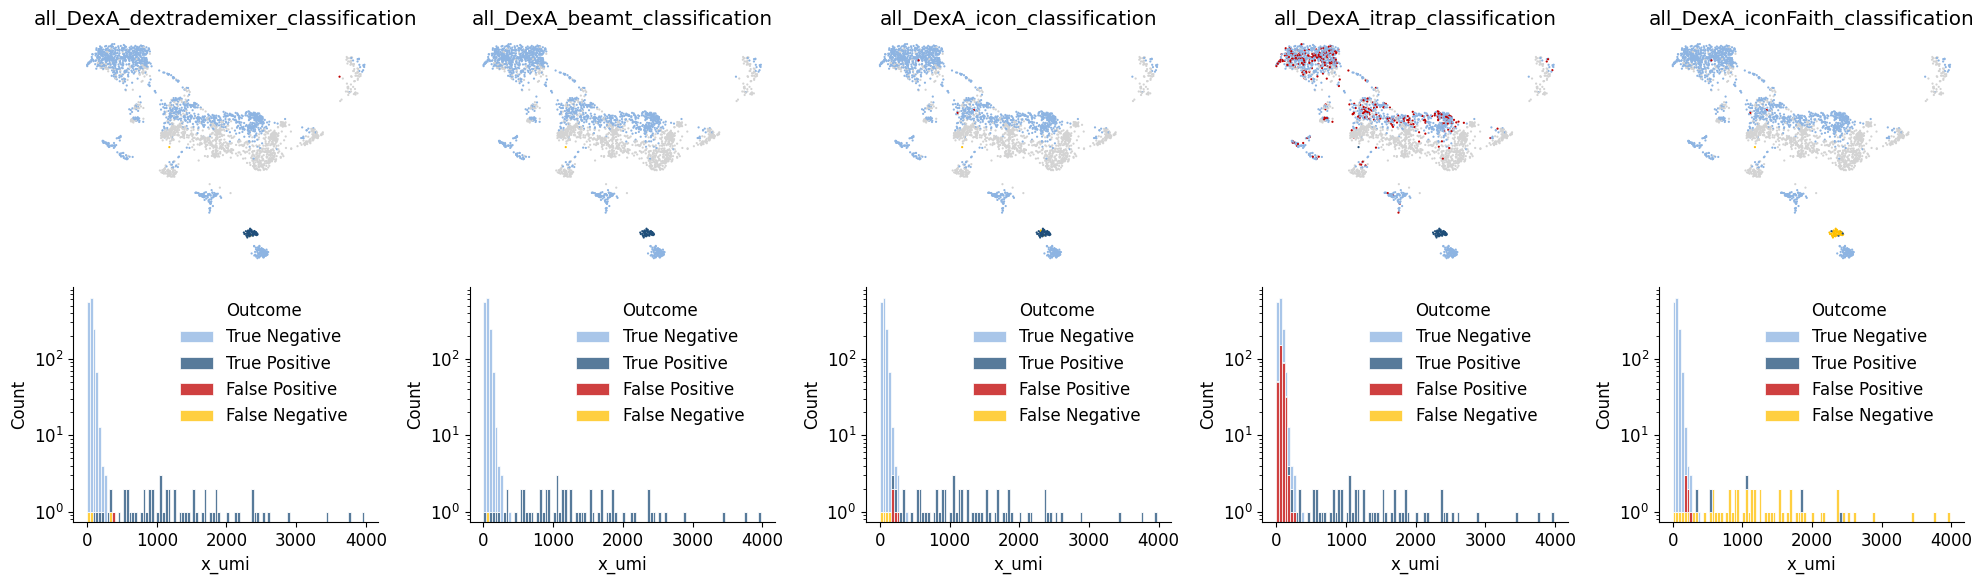

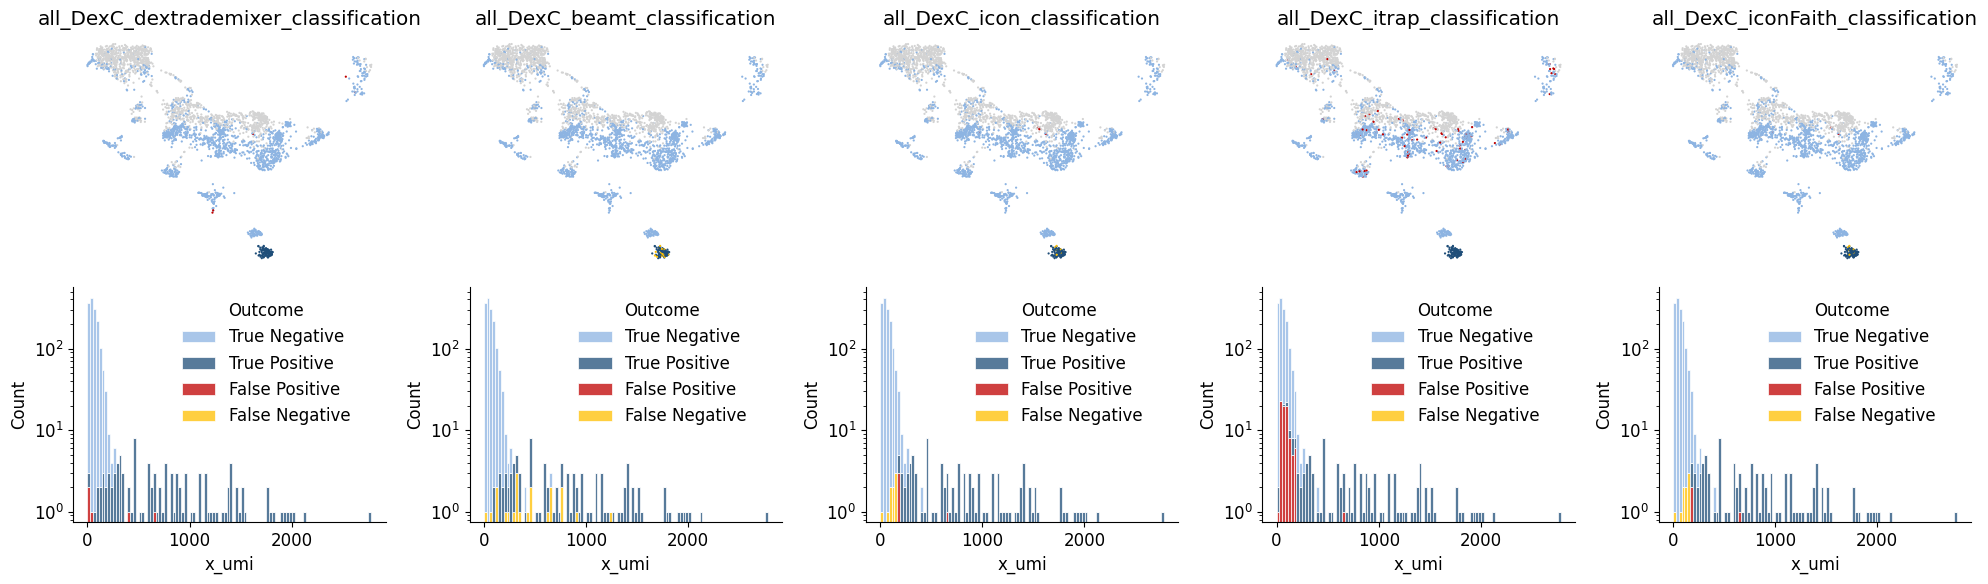

/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/24396870.py:77: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[f'{method}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])


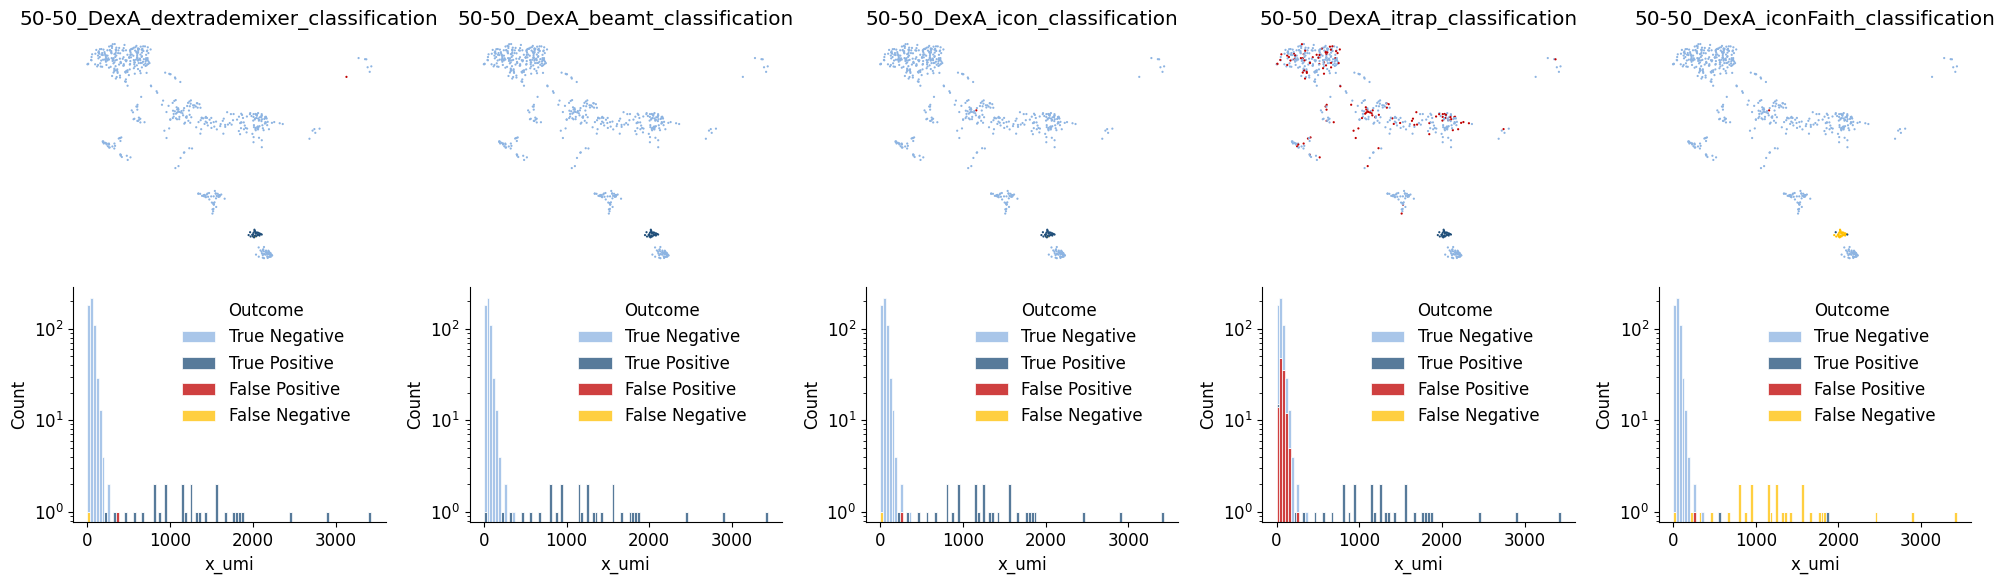

/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/24396870.py:77: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[f'{method}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])


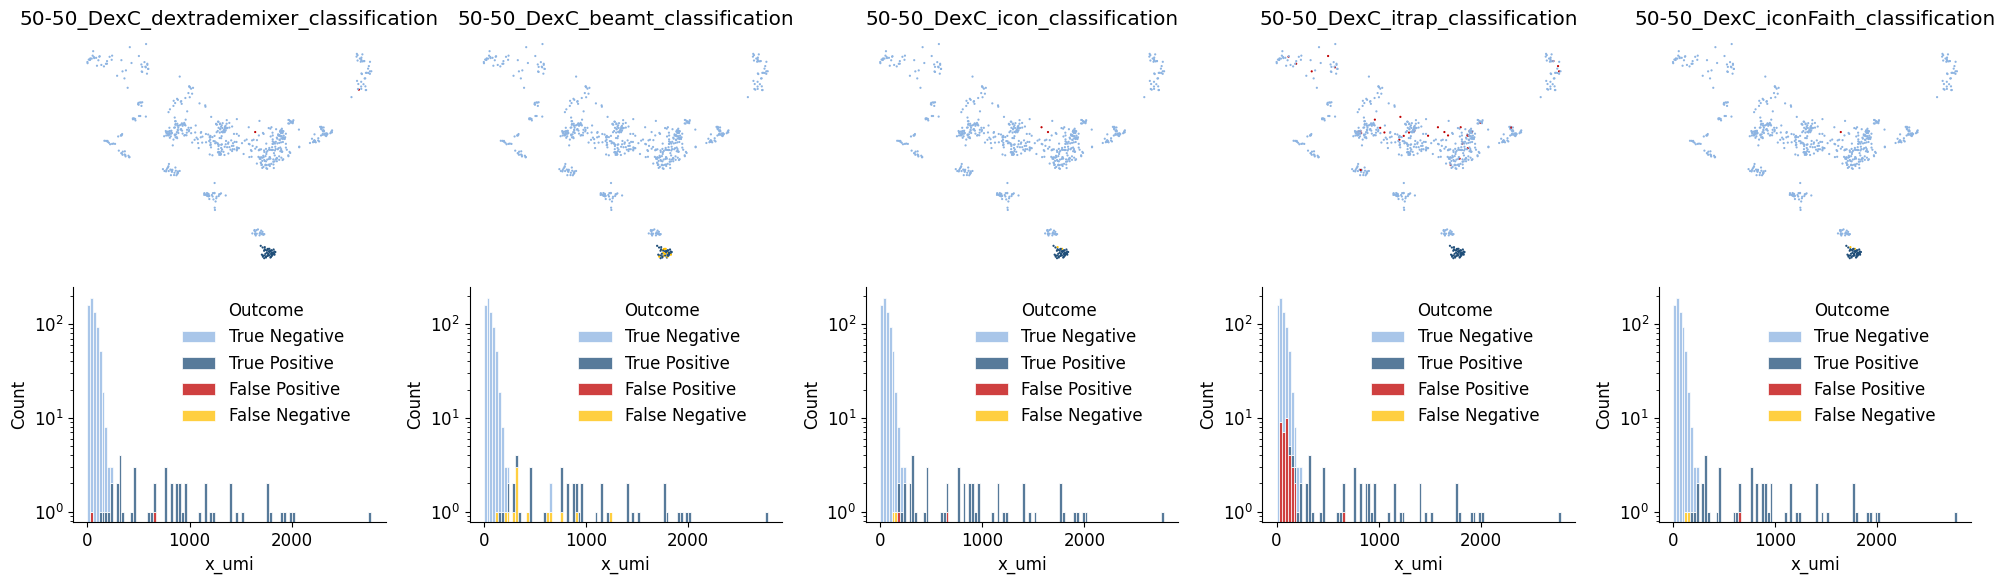

/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/24396870.py:77: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[f'{method}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])


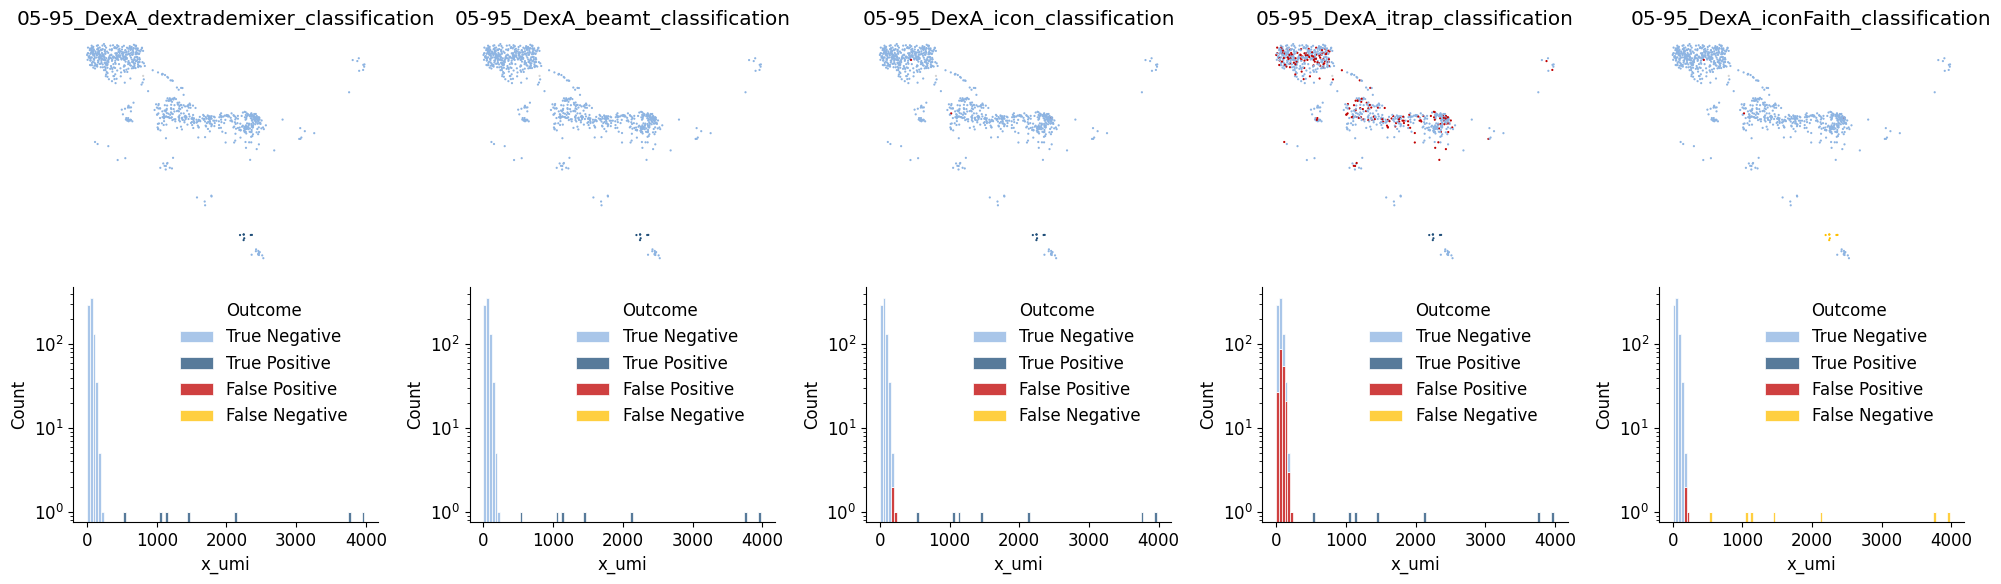

/var/folders/9k/rsnwv_zs49n5zryyfc4myl9d6b36ql/T/ipykernel_93455/24396870.py:77: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[f'{method}_classification'] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])


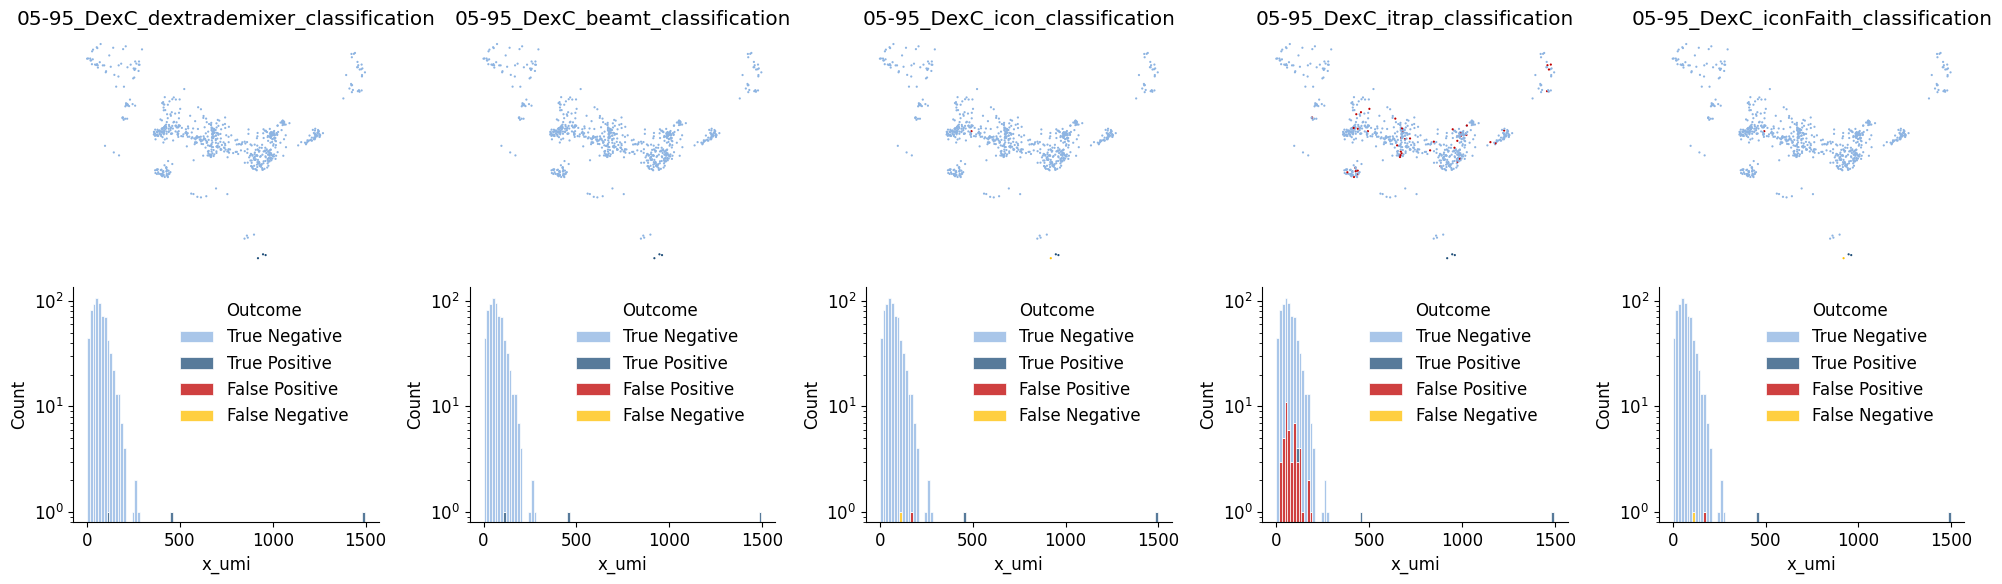

In [21]:
dex_map = {
    'DexA': {'ground_truth': 'NLV_true', 'HLA-match': 'D2'},
    'DexB': {'ground_truth': 'TPR_true', 'HLA-match': 'D1'},
    'DexC': {'ground_truth': 'CRV_true', 'HLA-match': 'D1'},
    
}
methods = ['dextrademixer','beamt', 'icon', 'itrap', 'iconFaith']
results = []

for spike_in in ['all','50-50','05-95']:
    for dextramer in ['DexA', 'DexC']:# , 'DexB']:
        fig, axes = plt.subplots(2, len(methods), figsize=(len(methods)*4, 2*3))
        
        sample = f"{spike_in}-{dex_map[dextramer]['HLA-match']}"
        if spike_in == 'all':
            adata = mdata_wTCR.copy()
        else:
            adata = mdata_wTCR[mdata_wTCR.obs["rna:Sample"] == sample]
        x_umi = adata.mod['rio'][:,dex_map_rev[dextramer]].X.toarray()[:, 0]
        
        for i, method in enumerate(methods):
            # get predictions
            ytrue = adata.obs[dex_map[dextramer]['ground_truth']].values
            ypred = adata.obs[f'{method}_{dextramer}'].values
            ppred = adata.obs[f'{method}_{dextramer}_p'] if f'{method}_{dextramer}_p' in adata.obs.columns else False

            # compute metrics
            setting = f'{dextramer},{sample}'
            result = {'dex_key': dextramer, 'model_config': method, 'sample': sample, 'tcr_info_sequenced_only': True, 'setting': setting, }
            metrics = eval_results(ytrue, ypred, ppred, adata, method=f'{spike_in}_{dextramer}_{method}')
            result.update(metrics)
            results.append(result)
            
            # plots
            axes[0,i] = mu.pl.embedding(
                adata, basis='rna:wnn.umap', color=f'{spike_in}_{dextramer}_{method}_classification', palette = ['#1F4E79','#8DB4E2','#FFC000','#C00000','lightgray'], 
                ncols=1, wspace=0.5, frameon=False, s=10, ax=axes[0,i], show=False, legend_loc=None
            )
            axes[1,i] = plot_confusion_hist(x_umi, ytrue, ypred, ax=axes[1,i])
        # plt.subplots_adjust(wspace=0.5)
        plt.tight_layout()
        plt.show()

### Boxplots per metric

In [25]:
metrics_list = ['f1','precision','recall','accuracy']
results_merged = pd.DataFrame(results)
results_merged = results_merged[results_merged.dex_key!='DexB']
results_melt = results_merged.sort_values(['setting', 'model_config']).melt(
    id_vars=['model_config', 'setting'], value_vars=metrics_list, var_name='metric', value_name='value'
)

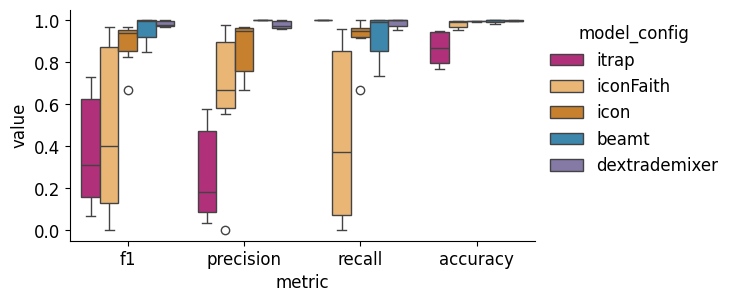

In [26]:
plt.figure(figsize=(6, 3))
ax = sns.boxplot(
    data=results_melt, x='metric', y='value', hue='model_config', palette=method_palette, order=metrics_list, hue_order=hue_order
)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.show()

### Barplots per setting

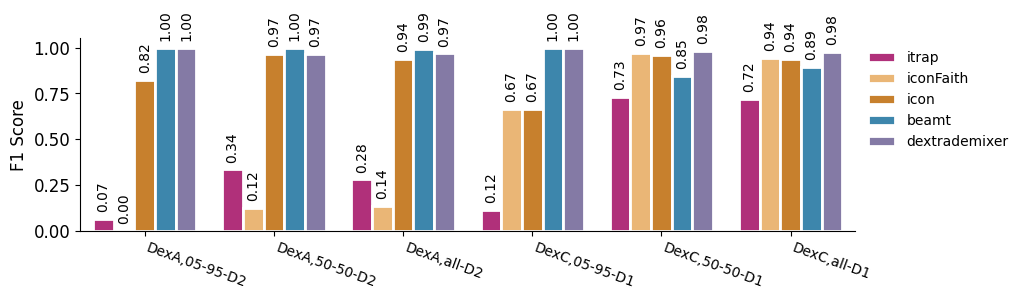

In [27]:
plt.figure(figsize=(10, 2.5))
ax = sns.barplot(
    results_merged.sort_values(['setting', 'model_config']), x='setting', y='f1', hue='model_config', palette=method_palette,
    hue_order=hue_order, width=0.8, edgecolor='white', linewidth=2
)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False, title='', fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize='small', label_type='edge', padding=5, rotation=90)

plt.xticks(rotation=-20, ha='left', fontsize='small')
plt.xlabel('')
plt.ylabel('F1 Score')
sns.despine()
# plt.savefig('../figures/cmv_f1_comparison.pdf')
plt.show()

### Head-to-head scatter

In [29]:
results_dextrademixer = results_merged[results_merged.model_config == 'dextrademixer']
results_dextrademixer.index = results_dextrademixer.setting
results_dextrademixer = results_dextrademixer.iloc[:,5:]
results_dextrademixer.columns = 'dextrademixer_' + results_dextrademixer.columns 
results_scatter = results_merged[results_merged.model_config != 'dextrademixer']
results_scatter.loc[:,results_dextrademixer.columns] = results_dextrademixer.loc[results_scatter.setting,:].values

In [30]:
results_scatter = results_scatter[results_scatter.model_config != 'iconFaith']
# results_scatter = results_scatter[~results_scatter['sample'].str.contains('all-')]

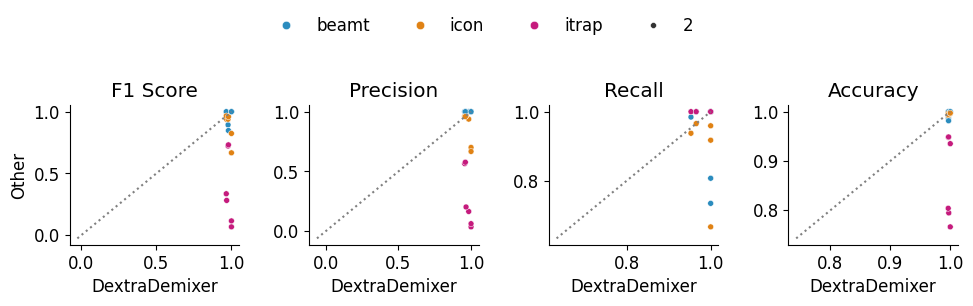

In [31]:
metrics = ['f1', 'precision', 'recall', 'accuracy', ]
title_map = {'pr_auc': 'PR AUC', 'roc_auc': 'ROC AUC', 'f1': 'F1 Score', 'precision': 'Precision', 'recall': 'Recall', 'accuracy': 'Accuracy'}
fig, axes = plt.subplots(1, len(metrics), figsize=(2.5 * len(metrics), 2.5))
legend_handles, legend_labels = None, None

for i, metric in enumerate(metrics):
    axes[i] = sns.scatterplot(
        results_scatter, x=f'dextrademixer_{metric}', y=metric, 
        ax=axes[i], legend=(i == 0), hue='model_config', palette=method_palette,
        size=2
    )

    if i == 0:
        legend_handles, legend_labels = axes[i].get_legend_handles_labels()
        if axes[i].legend_ is not None:
            axes[i].legend_.remove()

    min_value = results_scatter[metric].min()
    max_value = results_scatter[metric].max()
    diff = max_value - min_value
    axes[i].plot((min_value - diff * 0.1, 1), (min_value - diff * 0.1, 1), ls=':', c='grey')
    axes[i].set_title(title_map[metric])
    axes[i].set_ylabel('Other' if i == 0 else '')
    axes[i].set_xlabel('DextraDemixer')

fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4, frameon=False)

plt.tight_layout()
# plt.savefig('../figures/cmv_scatter_comparison.pdf')
plt.show()